In [6]:
from __future__ import print_function
import sys, os
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

import ROOT
from ROOT import gROOT, gStyle, gDirectory, gPad

import filepath 
import portROOT2pd
from pdgid import pdgid_dict
import plot_utils
import constants

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c0


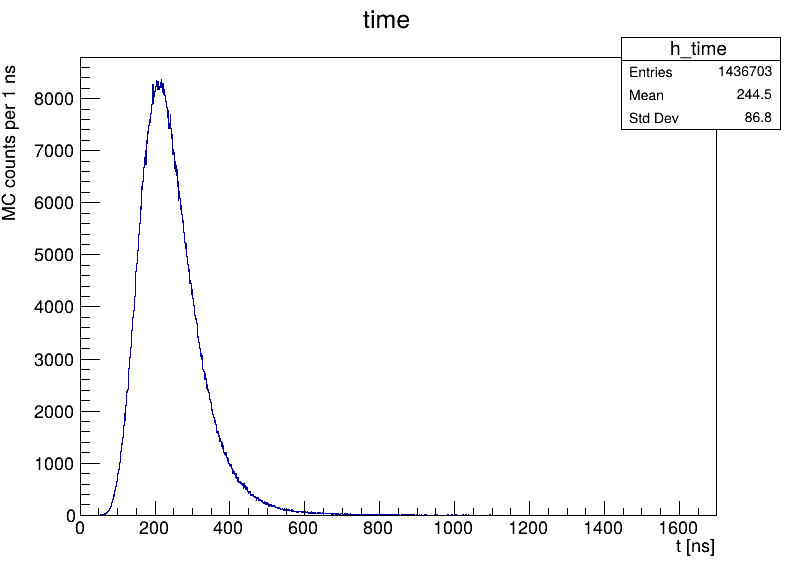

In [7]:
# get timing
rdf = ROOT.RDataFrame("Stage1virtualdetector/ttree", "tmp/TargetStopsCat_MDC2025ac_dump.root")
rdf = rdf.Filter("virtualdetectorId == 9") \
         .Filter("pdgId == 13") 
h_time = rdf.Histo1D(("h_time","time ;t [ns];MC counts per 1 ns", 1700, 0., 1700.), "time").GetValue()
h_time.SetDirectory(0)
c0 = ROOT.TCanvas("c0", "c0", 800, 600)
h_time.Draw()
c0.Draw()

Overall phase ratio <10 ns or >250 ns: 0.9074 (9074 / 10000)
Photon time-of-flight used: 0.1 ns
Period 0: count=8071, ratio=0.9516
Period 1: count=1662, ratio=0.7208
Period 2: count=239, ratio=0.7364
Period 3: count=26, ratio=0.7308
Period 4: count=1, ratio=0.0000
Period 5: count=1, ratio=1.0000


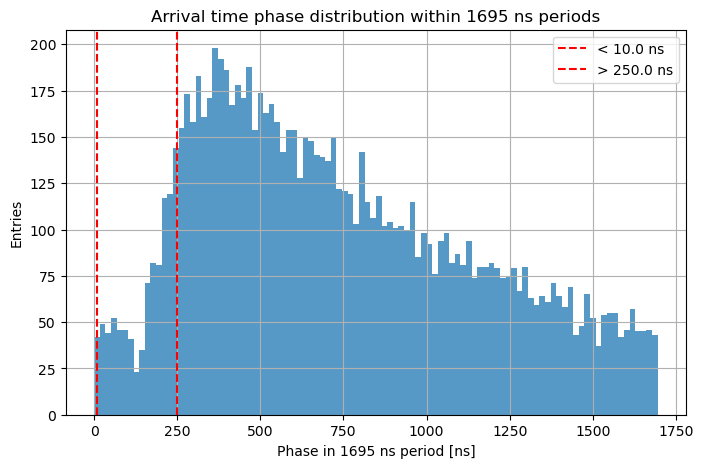

In [8]:
# do 10000 draws from h_time. each particle has a start time. after a lifetime, it decays and give off a photon, which propagates to VD101
# tally the time after the propagation ends. get a ratio of those <10 ns or >250 ns in each repeated 1695 ns period

lifetime = 864.7 # ns
n_draws = 10000
period = 1695.0
window_low = 10.0
window_high = 250.0

# approximate photon flight time from the stopping target region to VD101
target_z = 0.5 * (constants.stopping_target_start_Z + constants.stopping_target_end_Z)
stop_pos = np.array([constants.stopping_target_X, constants.stopping_target_Y, target_z])
vd101_pos = np.array([constants.VD101_X, constants.VD101_Y, constants.VD101_Z])
light_speed_mm_per_ns = 299792.458
photon_tof = np.linalg.norm(vd101_pos - stop_pos) / light_speed_mm_per_ns

np.random.seed(12345)
start_times = np.array([h_time.GetRandom() for _ in range(n_draws)])
decay_times = np.random.exponential(lifetime, size=n_draws)
arrival_times = start_times + decay_times + photon_tof

phases = arrival_times % period
window_mask = (phases < window_low) | (phases > window_high)
ratio_phase = np.count_nonzero(window_mask) / float(n_draws)

print(f"Overall phase ratio <{window_low:.0f} ns or >{window_high:.0f} ns: {ratio_phase:.4f} ({np.count_nonzero(window_mask)} / {n_draws})")
print(f"Photon time-of-flight used: {photon_tof:.1f} ns")

# compute ratio in each occupied period
period_indices = np.floor(arrival_times / period).astype(int)
unique_periods = np.unique(period_indices)
for idx in unique_periods:
    mask = period_indices == idx
    count_period = np.count_nonzero(mask)
    ratio_period = np.count_nonzero(window_mask & mask) / float(count_period)
    print(f"Period {idx}: count={count_period}, ratio={ratio_period:.4f}")

plt.figure(figsize=(8,5))
plt.hist(phases, bins=100, histtype='stepfilled', alpha=0.75)
plt.axvline(window_low, color='red', linestyle='--', label=f'< {window_low} ns')
plt.axvline(window_high, color='red', linestyle='--', label=f'> {window_high} ns')
plt.xlabel('Phase in 1695 ns period [ns]')
plt.ylabel('Entries')
plt.title('Arrival time phase distribution within 1695 ns periods')
plt.legend()
plt.grid(True)
plt.show()